In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import load_model
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess_input


2026-05-09 10:06:42.259649: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778321202.529584      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778321202.610926      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778321203.316700      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778321203.316766      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778321203.316772      16 computation_placer.cc:177] computation placer alr

In [2]:
resnet_model_path = r"/kaggle/input/models/mistblade69/resnetmobilenet-mods/keras/default/1/resnet50_tumor_model.keras"

mobilenet_model_path = r"/kaggle/input/models/mistblade69/resnetmobilenet-mods/keras/default/1/tumor_mobilenetv2_image.keras"

image_path = r"/kaggle/input/datasets/mistblade69/brisc-dataset2025/brisc2025/classification_task/test/pituitary/brisc2025_test_00714_pi_ax_t1.jpg"

IMG_SIZE = (224, 224)

class_names = ["glioma", "meningioma", "no_tumor", "pituitary"]


In [3]:
resnet_model = load_model(resnet_model_path,compile=False)
mobilenet_model = load_model(mobilenet_model_path, compile=False)

print("ResNet loaded")
print("MobileNetV2 loaded")

resnet_gradcam_layer = "resnet50"
mobilenet_gradcam_layer = "mobilenetv2_1.00_224"

2026-05-09 10:07:12.872069: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


ResNet loaded
MobileNetV2 loaded


In [4]:
def load_image(path):
    img = load_img(path, target_size=IMG_SIZE)
    arr = img_to_array(img)
    arr = np.expand_dims(arr, axis=0).astype("float32")
    return img, arr

original_img, img_array = load_image(image_path)

def preprocess_resnet(x):
    return resnet_preprocess_input(tf.identity(x))

def preprocess_mobilenet(x):
    return tf.identity(x) / 255.0

def predict_model(model, img_array, preprocess_fn):
    x = preprocess_fn(img_array)
    probs = model(x, training=False).numpy()[0]
    class_id = int(np.argmax(probs))
    return class_id, class_names[class_id], float(probs[class_id]), probs

resnet_class_id, resnet_class, resnet_conf, resnet_probs = predict_model(
    resnet_model, img_array, preprocess_resnet
)

mobilenet_class_id, mobilenet_class, mobilenet_conf, mobilenet_probs = predict_model(
    mobilenet_model, img_array, preprocess_mobilenet
)

In [5]:
print("ResNet:", resnet_class, resnet_conf)
print("MobileNetV2:", mobilenet_class, mobilenet_conf)

ResNet: pituitary 0.9999991655349731
MobileNetV2: pituitary 0.9999808073043823


,Class,ResNet,MobileNetV2
0,glioma,1.389494e-10,4.679653e-08
1,meningioma,7.915971e-07,1.913808e-05
2,no_tumor,1.457191e-10,1.512492e-09
3,pituitary,9.999992e-01,9.999808e-01


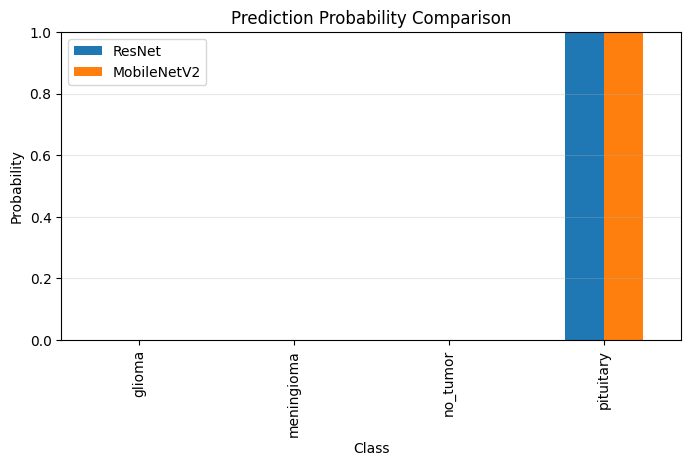

In [6]:
prob_df = pd.DataFrame({
    "Class": class_names,
    "ResNet": resnet_probs,
    "MobileNetV2": mobilenet_probs
})

display(prob_df)

prob_df.plot(x="Class", y=["ResNet", "MobileNetV2"], kind="bar", figsize=(8, 4))
plt.ylim(0, 1)
plt.ylabel("Probability")
plt.title("Prediction Probability Comparison")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [7]:
def call_layer(layer, x):
    try:
        return layer(x, training=False)
    except TypeError:
        return layer(x)


def build_feature_extractor_and_classifier(model, target_layer_name):
    target_layer = model.get_layer(target_layer_name)

    feature_input = tf.keras.Input(shape=model.input_shape[1:])
    x = feature_input

    reached_target = False
    for layer in model.layers[1:]:
        x = call_layer(layer, x)

        if layer.name == target_layer_name:
            reached_target = True
            break

    if not reached_target:
        raise ValueError(f"Layer {target_layer_name} not found in model")

    feature_extractor = tf.keras.Model(feature_input, x)

    classifier_input = tf.keras.Input(shape=target_layer.output.shape[1:])
    y = classifier_input

    use_head = False
    for layer in model.layers[1:]:
        if use_head:
            y = call_layer(layer, y)

        if layer.name == target_layer_name:
            use_head = True

    classifier = tf.keras.Model(classifier_input, y)

    return feature_extractor, classifier


In [8]:
def make_gradcam(model, img_array, preprocess_fn, class_id, layer_name):
    feature_extractor, classifier = build_feature_extractor_and_classifier(
        model,
        layer_name
    )

    with tf.GradientTape() as tape:
        x = preprocess_fn(img_array)
        feature_maps = feature_extractor(x, training=False)
        tape.watch(feature_maps)

        predictions = classifier(feature_maps, training=False)
        class_score = predictions[:, class_id]

    gradients = tape.gradient(class_score, feature_maps)

    pooled_gradients = tf.reduce_mean(gradients, axis=(0, 1, 2))

    feature_maps = feature_maps[0]
    heatmap = tf.reduce_sum(feature_maps * pooled_gradients, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()


resnet_gradcam_layer="resnet50"
mobilenet_gradcam_layer ="mobilenetv2_1.00_224"



In [9]:
resnet_gradcam = make_gradcam(
    resnet_model, img_array, preprocess_resnet, resnet_class_id, resnet_gradcam_layer
)

mobilenet_gradcam = make_gradcam(
    mobilenet_model, img_array, preprocess_mobilenet, mobilenet_class_id, mobilenet_gradcam_layer
)

def overlay_heatmap(img, heatmap, alpha=0.45, cmap="jet"):
    img = np.array(img).astype("float32") / 255.0
    heatmap = tf.image.resize(heatmap[..., np.newaxis], IMG_SIZE).numpy().squeeze()

    color_map = plt.get_cmap(cmap)
    colored_heatmap = color_map(heatmap)[:, :, :3]

    overlay = (1 - alpha) * img + alpha * colored_heatmap
    return np.clip(overlay, 0, 1)

In [10]:
def integrated_gradients(model, img_array, preprocess_fn, class_id, steps=32):
    img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)
    baseline = tf.zeros_like(img_tensor)

    alphas = tf.linspace(0.0, 1.0, steps + 1)
    interpolated = baseline + alphas[:, None, None, None] * (img_tensor - baseline)

    with tf.GradientTape() as tape:
        tape.watch(interpolated)
        x = preprocess_fn(interpolated)
        predictions = model(x, training=False)
        class_scores = predictions[:, class_id]

    gradients = tape.gradient(class_scores, interpolated)
    avg_gradients = tf.reduce_mean(gradients[:-1], axis=0)

    integrated_grads = (img_tensor[0] - baseline[0]) * avg_gradients
    attribution = tf.reduce_sum(tf.abs(integrated_grads), axis=-1)
    attribution = attribution / (tf.reduce_max(attribution) + 1e-8)

    return attribution.numpy()



In [11]:
resnet_ig = integrated_gradients(
    resnet_model, img_array, preprocess_resnet, resnet_class_id
)

mobilenet_ig = integrated_gradients(
    mobilenet_model, img_array, preprocess_mobilenet, mobilenet_class_id
)

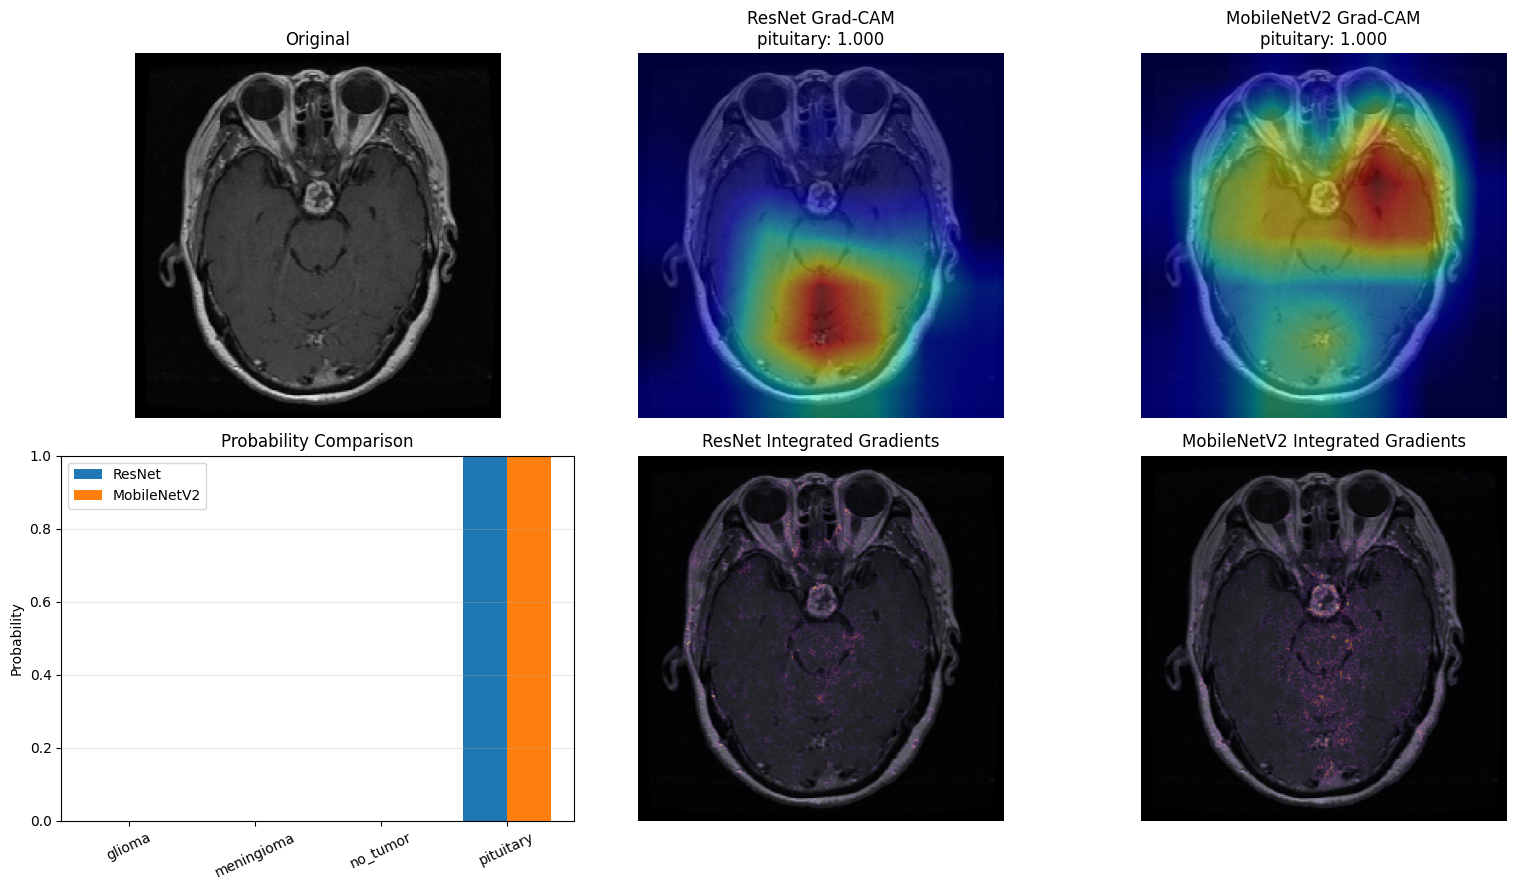

Both models predicted: pituitary


In [12]:
plt.figure(figsize=(16, 9))

plt.subplot(2, 3, 1)
plt.imshow(original_img)
plt.title("Original")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(overlay_heatmap(original_img, resnet_gradcam))
plt.title(f"ResNet Grad-CAM\n{resnet_class}: {resnet_conf:.3f}")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(overlay_heatmap(original_img, mobilenet_gradcam))
plt.title(f"MobileNetV2 Grad-CAM\n{mobilenet_class}: {mobilenet_conf:.3f}")
plt.axis("off")

plt.subplot(2, 3, 4)
x = np.arange(len(class_names))
width = 0.35
plt.bar(x - width / 2, resnet_probs, width, label="ResNet")
plt.bar(x + width / 2, mobilenet_probs, width, label="MobileNetV2")
plt.xticks(x, class_names, rotation=25)
plt.ylim(0, 1)
plt.ylabel("Probability")
plt.title("Probability Comparison")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.subplot(2, 3, 5)
plt.imshow(overlay_heatmap(original_img, resnet_ig, cmap="inferno"))
plt.title("ResNet Integrated Gradients")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(overlay_heatmap(original_img, mobilenet_ig, cmap="inferno"))
plt.title("MobileNetV2 Integrated Gradients")
plt.axis("off")

plt.tight_layout()
plt.show()

if resnet_class_id == mobilenet_class_id:
    print("Both models predicted:", resnet_class)
else:
    print("Models disagree")
    print("ResNet predicted:", resnet_class, resnet_conf)
    print("MobileNetV2 predicted:", mobilenet_class, mobilenet_conf)

In [13]:
save_path = "/kaggle/working/"

plt.imsave(
    save_path + "resnet_gradcam.jpg",
    overlay_heatmap(original_img, resnet_gradcam)
)

plt.imsave(
    save_path + "mobilenet_gradcam.jpg",
    overlay_heatmap(original_img, mobilenet_gradcam)
)

plt.imsave(
    save_path + "resnet_integrated_gradients.jpg",
    overlay_heatmap(original_img, resnet_ig, cmap="inferno")
)

plt.imsave(
    save_path + "mobilenet_integrated_gradients.jpg",
    overlay_heatmap(original_img, mobilenet_ig, cmap="inferno")
)


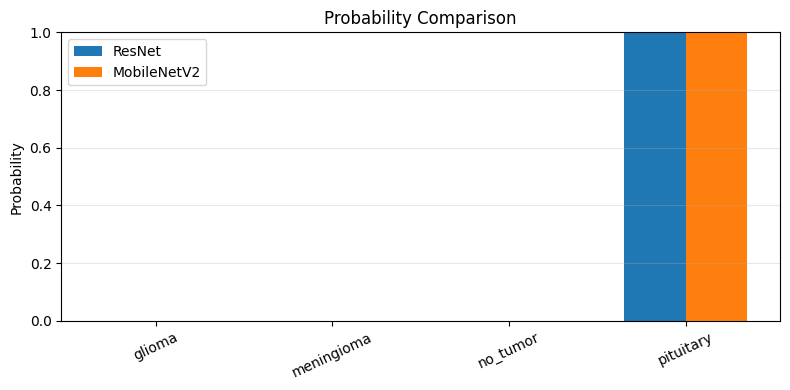

In [14]:
plt.figure(figsize=(8, 4))

x = np.arange(len(class_names))
width = 0.35

plt.bar(x - width / 2, resnet_probs, width, label="ResNet")
plt.bar(x + width / 2, mobilenet_probs, width, label="MobileNetV2")

plt.xticks(x, class_names, rotation=25)
plt.ylim(0, 1)
plt.ylabel("Probability")
plt.title("Probability Comparison")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/probability_comparison.jpg", dpi=300, bbox_inches="tight")
plt.show()


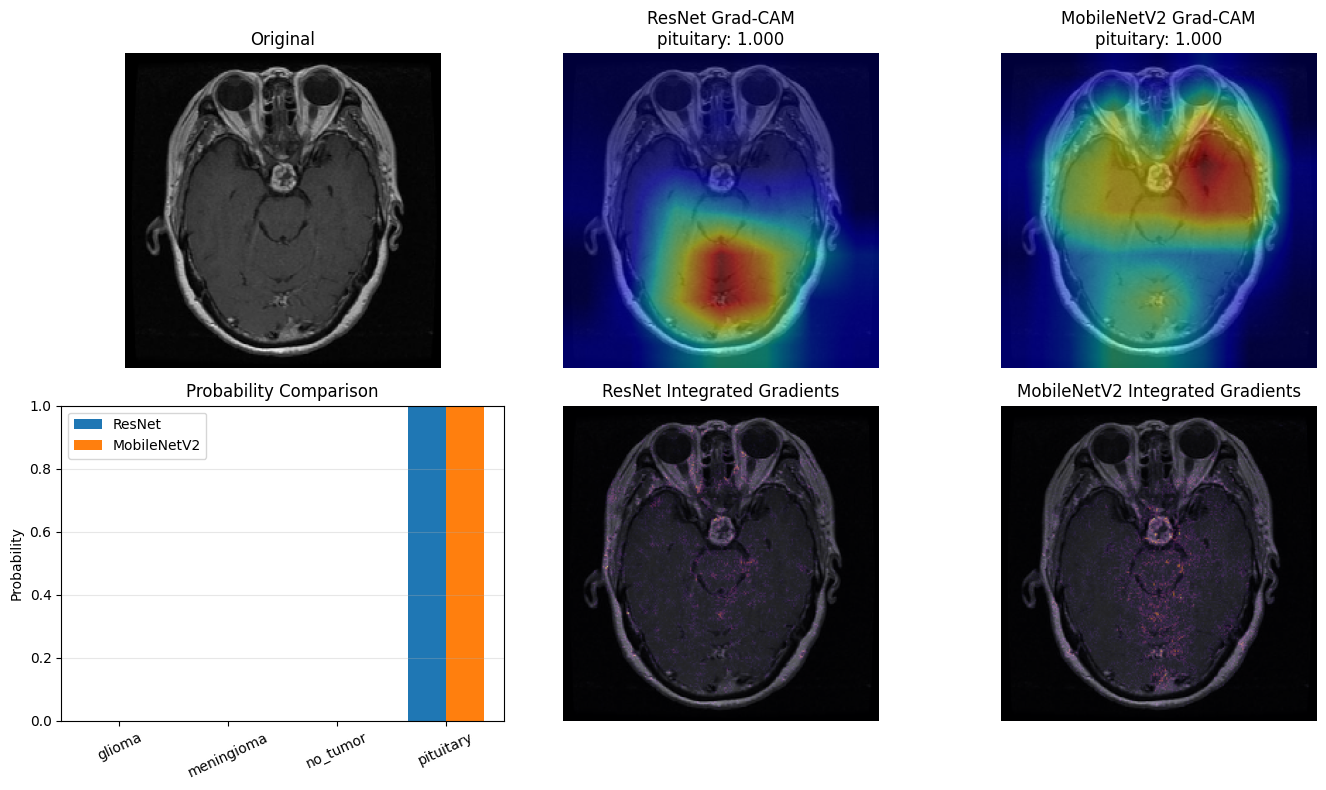

In [15]:
plt.figure(figsize=(14, 8))

plt.subplot(2, 3, 1)
plt.imshow(original_img)
plt.title("Original")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(overlay_heatmap(original_img, resnet_gradcam))
plt.title(f"ResNet Grad-CAM\n{resnet_class}: {resnet_conf:.3f}")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(overlay_heatmap(original_img, mobilenet_gradcam))
plt.title(f"MobileNetV2 Grad-CAM\n{mobilenet_class}: {mobilenet_conf:.3f}")
plt.axis("off")

plt.subplot(2, 3, 4)
x = np.arange(len(class_names))
width = 0.35

plt.bar(x - width / 2, resnet_probs, width, label="ResNet")
plt.bar(x + width / 2, mobilenet_probs, width, label="MobileNetV2")

plt.xticks(x, class_names, rotation=25)
plt.ylim(0, 1)
plt.ylabel("Probability")
plt.title("Probability Comparison")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.subplot(2, 3, 5)
plt.imshow(overlay_heatmap(original_img, resnet_ig, cmap="inferno"))
plt.title("ResNet Integrated Gradients")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(overlay_heatmap(original_img, mobilenet_ig, cmap="inferno"))
plt.title("MobileNetV2 Integrated Gradients")
plt.axis("off")

plt.tight_layout()
plt.savefig("/kaggle/working/xai_comparison.jpg", dpi=300, bbox_inches="tight")

plt.show()
